In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
degradation_trajectory = {}

## MIT battery dataset

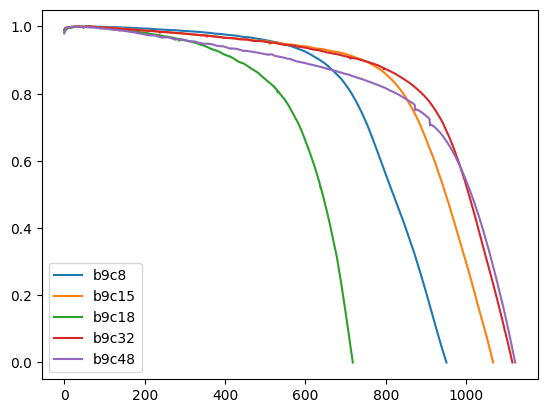

In [2]:
keys = ['b9c8', 'b9c15', 'b9c18', 'b9c32', 'b9c48']
batch = np.load('../../data/raw/batch9.pkl', allow_pickle=True)
for key in keys:
    capacity = scaler.fit_transform(batch[key]['summary']['QD'].reshape(-1, 1))
    degradation_trajectory[f'mit_{key}'] = np.array(capacity).flatten()
    plt.plot(capacity, label=f'{key}')
plt.legend()

## TRI battery dataset

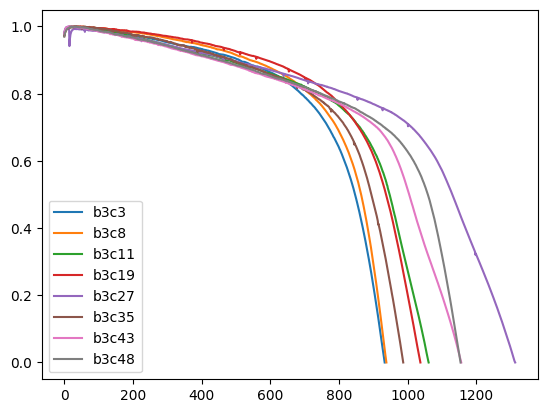

In [3]:
keys = ['b3c3', 'b3c8', 'b3c11', 'b3c19', 'b3c27', 'b3c35', 'b3c43', 'b3c48']
batch = np.load('../../data/raw/batch3.pkl', allow_pickle=True)
for key in keys:
    capacity = scaler.fit_transform(batch[key]['summary']['QD'].reshape(-1, 1))
    degradation_trajectory[f'tri_{key}'] = np.array(capacity).flatten()
    plt.plot(capacity, label=f'{key}')
plt.legend()

## TJU battery dataset

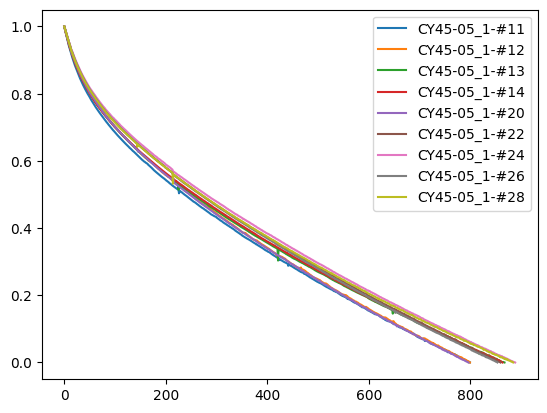

In [4]:
keys = ['CY45-05_1-#11', 'CY45-05_1-#12', 'CY45-05_1-#13', 'CY45-05_1-#14', 'CY45-05_1-#20', 'CY45-05_1-#22', 'CY45-05_1-#24', 'CY45-05_1-#26', 'CY45-05_1-#28']
for key in keys:
    data = np.load(os.path.join('../../data/raw/tongji', key + '.pkl'), allow_pickle=True)
    capacity = []
    for sample in data:
        capacity.append(sample[1][1])
    capacity = scaler.fit_transform(np.array(capacity).reshape(-1, 1))
    degradation_trajectory[f'tju_{key}'] = capacity.flatten()
    plt.plot(capacity, label=f'{key}')
plt.legend()

mit_b9c8 952
mit_b9c15 1068
mit_b9c18 719
mit_b9c32 1116
mit_b9c48 1123
tri_b3c3 934
tri_b3c8 939
tri_b3c11 1062
tri_b3c19 1038
tri_b3c27 1314
tri_b3c35 988
tri_b3c43 1157
tri_b3c48 1155
tju_CY45-05_1-#11 800
tju_CY45-05_1-#12 800
tju_CY45-05_1-#13 868
tju_CY45-05_1-#14 864
tju_CY45-05_1-#20 797
tju_CY45-05_1-#22 860
tju_CY45-05_1-#24 889
tju_CY45-05_1-#26 854
tju_CY45-05_1-#28 885


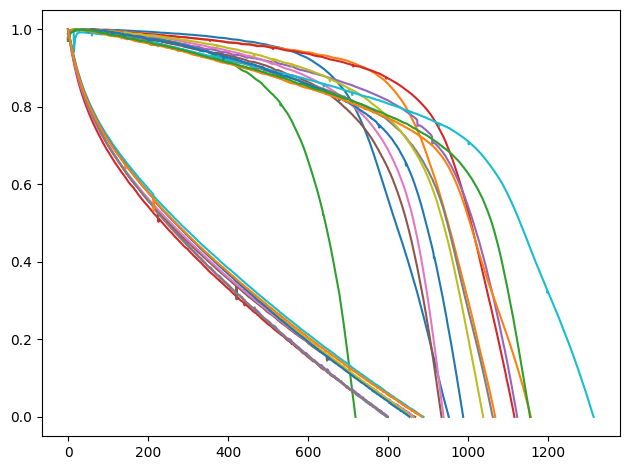

In [6]:
df = pd.DataFrame()
for key in degradation_trajectory.keys():
    data_dict = {key: degradation_trajectory[key]}
    data_df = pd.DataFrame(data_dict)
    df = pd.concat((df, data_df), axis=1)
    plt.plot(degradation_trajectory[key], label=f'{key}')
    print(key, len(degradation_trajectory[key]))
# plt.axhline(0.8, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('output.png')

# for dataset in ['mit', 'tri', 'tju']:
#     print(np.array([len(degradation_trajectory[key]) for key in degradation_trajectory.keys() if dataset in key]).mean())

df.to_excel('output.xlsx')
